# Wind-blown snow TFT sandbox
- Encoder inputs: wind/air state/flux proxies (+ optional spectra, stability/quality dummies).
- Decoder known future: solar_radiation_wm2, wind_direction_deg.
- Targets: air_temperature_c, wind_speed_ms, snow_mass_flux_kg_m2_s, snow_surface_temperature_c.
- Physics penalty + load calculations are imported from helper modules.


### 说明：路径与模块初始化
- 优先定位仓库根目录（需包含 `legacy/src/data`），避免在 `legacy/windblown_snow` 内部运行时误判根目录。
- 计算 legacy dummy 的根路径 `LEGACY_ROOT`，并将 `legacy/windblown_snow/src` 加入 `sys.path`。
- 导入自定义组件：轻量级 Transformer `SnowTFT`、窗口数据加载器 `build_loaders`、物理正则 `physics_penalty` 与载荷计算工具。
- 固定随机种子以便复现实验。


In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from pathlib import Path
import sys

def find_repo_root(markers=('legacy', 'src', 'data')):
    p = Path.cwd()
    for _ in range(8):
        if all((p / m).exists() for m in markers):
            return p
        if p.parent == p:
            break
        p = p.parent
    return Path.cwd()

ROOT = find_repo_root()
LEGACY_ROOT = ROOT / 'legacy' / 'windblown_snow'
if not LEGACY_ROOT.exists():
    if (ROOT / 'train_dummy.ipynb').exists() and (ROOT / 'src').exists():
        LEGACY_ROOT = ROOT
    else:
        raise FileNotFoundError('Cannot locate legacy/windblown_snow root')

src_path = LEGACY_ROOT / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

for name in ('tft_model', 'snow_dataset', 'physics_losses', 'physics_calculations'):
    if name in sys.modules:
        del sys.modules[name]

from tft_model import SnowTFT
from snow_dataset import build_loaders
from physics_losses import physics_penalty
from physics_calculations import ParticleBin, summarize_loads

torch.manual_seed(0)
np.random.seed(0)


### 说明：基本配置与列定义
- 指定合成数据路径与时间窗口/预测步长 (`window_size=24`, `horizon=6`) 以及训练比例、批大小。
- 列出编码器已知历史特征 `KNOWN_COLS`（风/气状态、历史雪通量/雪面温度与能量估计），解码器的未来已知协变量 `KNOWN_FUTURE_COLS`（辐射与风向）。
- 定义多目标输出列 `TARGET_COLS`，并预留 `SPECTRUM_COLS` 用于可选粒径/速度谱特征。


In [2]:
data_path = LEGACY_ROOT / 'data/synthetic/windblown_snow_sample.csv'
window_size = 24  # encoder length
horizon = 6       # decoder length
train_ratio = 0.8
batch_size = 64

# Encoder known history
KNOWN_COLS = [
    'wind_speed_ms', 'air_temperature_c', 'snow_surface_temperature_c', 'snow_mass_flux_kg_m2_s',
    'relative_humidity', 'air_pressure_pa',
    'turbulence_intensity', 'friction_velocity_ms', 'ri_bulk',
    'wind_snow_coupling', 'threshold_exceedance',
    'net_radiation_est', 'sensible_heat_flux_est', 'latent_heat_flux_est',
]
# Decoder known future covariates
KNOWN_FUTURE_COLS = ['solar_radiation_wm2', 'wind_direction_deg']

TARGET_COLS = [
    'air_temperature_c',
    'wind_speed_ms',
    'snow_mass_flux_kg_m2_s',
    'snow_surface_temperature_c',
]
SPECTRUM_COLS = []


### 说明：数据读取与特征工程
- 读取 CSV、解析时间戳，并自动捕捉 `size_bin_*`/`velocity_bin_*` 频谱列以便作为已知特征加入。
- 将稳定度/质量/数据源类别做独热编码并附加到特征集合，校验必需的目标列是否齐全。
- 按时间排序后拆分出特征与目标矩阵，对特征与目标分别做 z-score 归一化，并保留均值/标准差向量用于反归一化（物理正则与绘图）。


In [3]:
df = pd.read_csv(data_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])

SPECTRUM_COLS = [c for c in df.columns if c.startswith(('size_bin_', 'velocity_bin_'))]
use_spectra_as_known = True
KNOWN = KNOWN_COLS + KNOWN_FUTURE_COLS + (SPECTRUM_COLS if use_spectra_as_known else [])

df = pd.get_dummies(df, columns=['stability_flag', 'quality_flag', 'data_source'], drop_first=True)
KNOWN += [c for c in df.columns if c.startswith(('stability_flag_', 'quality_flag_', 'data_source_'))]

for col in TARGET_COLS:
    if col not in df.columns:
        raise ValueError(f'Missing target column: {col}')

feature_df = df.sort_values('timestamp').reset_index(drop=True)
features = feature_df[KNOWN].to_numpy(dtype=np.float32)
targets = feature_df[TARGET_COLS].to_numpy(dtype=np.float32)

feat_mean = features.mean(axis=0, keepdims=True)
feat_std = features.std(axis=0, keepdims=True) + 1e-6
features = (features - feat_mean) / feat_std
feat_mean_vec = feat_mean.squeeze()
feat_std_vec = feat_std.squeeze()

target_mean = targets.mean(axis=0, keepdims=True)
target_std = targets.std(axis=0, keepdims=True) + 1e-6
targets_norm = (targets - target_mean) / target_std
tgt_mean_vec = target_mean.squeeze()
tgt_std_vec = target_std.squeeze()

print('features shape', features.shape, 'targets shape', targets.shape)


features shape (2000, 38) targets shape (2000, 4)


### 说明：构建数据加载器
- 根据 `KNOWN_FUTURE_COLS` 生成未来协变量在特征矩阵中的索引。
- 调用 `build_loaders` 按时间切分训练/验证集（验证集覆盖末段并包含回看窗口），生成用于 TFT 的训练/验证 DataLoader，并打印批次数。


In [4]:
future_known_idx = [KNOWN.index(c) for c in KNOWN_FUTURE_COLS]
loaders = build_loaders(
    features,
    targets_norm,
    window_size,
    horizon,
    train_ratio=train_ratio,
    batch_size=batch_size,
    future_known_idx=future_known_idx,
)
train_loader, val_loader = loaders.train, loaders.val
print('train batches', len(train_loader), 'val batches', len(val_loader))


train batches 25 val batches 7


### 说明：模型与优化器设置
- 选择可用设备（优先 GPU），实例化 `SnowTFT`，输入/输出/未来特征维度与模型宽度、头数、层数在此配置。
- 使用 Adam 优化器与均方误差损失；将特征与目标的均值/标准差搬到设备上，便于物理约束与反归一化。


In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SnowTFT(
    input_dim=len(KNOWN),
    target_dim=len(TARGET_COLS),
    known_future_dim=len(future_known_idx),
    d_model=128,
    nhead=4,
    num_layers=2,
).to(device)
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

feat_mean_t = torch.tensor(feat_mean_vec, device=device)
feat_std_t = torch.tensor(feat_std_vec, device=device)
tgt_mean_t = torch.tensor(tgt_mean_vec, device=device)
tgt_std_t = torch.tensor(tgt_std_vec, device=device)

pin_weight = 0.01


## PINN / physics loss hook
`physics_penalty` is imported from `physics_losses.py`; adjust it there for new constraints.


### 说明：训练循环（含物理正则）
- 为特征列建立名称到索引的映射，便于物理约束查找。
- `run_epoch` 在归一化空间计算 MSE，同时将预测反归一化后计算 `physics_penalty`（约束风阈值、摩阻单调、湿度/辐射/稳定度抑制等）。
- 运行若干 epoch，逐轮输出训练/验证损失（含 MSE 与 PINN 项），便于观察收敛情况。


In [6]:
idx_map = {c: i for i, c in enumerate(KNOWN)}

def run_epoch(loader, train: bool = True):
    model.train(train)
    total_loss = 0.0
    total_mse = 0.0
    total_pin = 0.0
    for xb, fb, yb in loader:
        xb = xb.to(device)
        fb = fb.to(device)
        yb = yb.to(device)
        if train:
            optim.zero_grad()
        preds = model(xb, fb)
        mse = loss_fn(preds, yb)
        preds_phys = preds * tgt_std_t + tgt_mean_t
        pin = physics_penalty(
            xb,
            preds_phys,
            KNOWN,
            feat_mean_t,
            feat_std_t,
            index_map=idx_map,
            target_cols=TARGET_COLS,
        )
        loss = mse + pin_weight * pin
        if train:
            loss.backward()
            optim.step()
        batch_size = len(xb)
        total_loss += loss.item() * batch_size
        total_mse += mse.item() * batch_size
        total_pin += pin.item() * batch_size
    denom = max(len(loader.dataset), 1)
    return total_loss / denom, total_mse / denom, total_pin / denom

for epoch in range(20):
    train_loss, train_mse, train_pin = run_epoch(train_loader, train=True)
    val_loss, val_mse, val_pin = run_epoch(val_loader, train=False)
    print(
        f'Epoch {epoch}: train {train_loss:.4f} (mse {train_mse:.4f}, pin {train_pin:.4f}) '
        f'val {val_loss:.4f} (mse {val_mse:.4f}, pin {val_pin:.4f})'
    )


Epoch 0: train 0.7929 (mse 0.7901, pin 0.2775) val 0.6679 (mse 0.6653, pin 0.2573)
Epoch 1: train 0.2861 (mse 0.2829, pin 0.3203) val 0.5055 (mse 0.5036, pin 0.1878)
Epoch 2: train 0.2327 (mse 0.2299, pin 0.2862) val 0.4732 (mse 0.4715, pin 0.1724)
Epoch 3: train 0.2157 (mse 0.2128, pin 0.2887) val 0.4621 (mse 0.4604, pin 0.1715)
Epoch 4: train 0.1965 (mse 0.1936, pin 0.2947) val 0.4522 (mse 0.4503, pin 0.1910)
Epoch 5: train 0.1835 (mse 0.1804, pin 0.3140) val 0.4254 (mse 0.4235, pin 0.1953)
Epoch 6: train 0.1691 (mse 0.1660, pin 0.3102) val 0.4773 (mse 0.4751, pin 0.2274)
Epoch 7: train 0.1573 (mse 0.1541, pin 0.3169) val 0.4562 (mse 0.4542, pin 0.2067)
Epoch 8: train 0.1478 (mse 0.1447, pin 0.3019) val 0.5303 (mse 0.5281, pin 0.2192)
Epoch 9: train 0.1464 (mse 0.1433, pin 0.3129) val 0.4217 (mse 0.4196, pin 0.2153)
Epoch 10: train 0.1328 (mse 0.1294, pin 0.3414) val 0.4535 (mse 0.4514, pin 0.2112)
Epoch 11: train 0.1314 (mse 0.1281, pin 0.3263) val 0.4458 (mse 0.4439, pin 0.1957)
Ep

### 说明：单批验证可视化
- 切换评估模式并从验证集抓取一批样本，生成预测序列。
- 将预测反归一化后逐目标绘制真值与预测的时间步曲线，对齐 horizon，快速查看多目标预测质量。


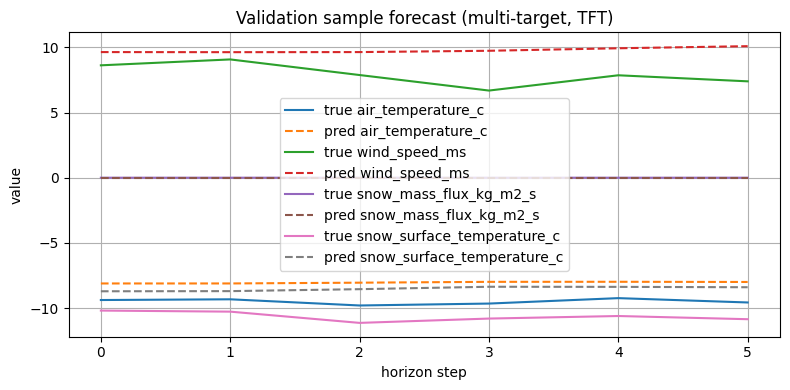

In [7]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    xb, fb, yb = next(iter(val_loader))
    xb, fb, yb = xb.to(device), fb.to(device), yb.to(device)
    preds = model(xb, fb).cpu().numpy()
    yb = yb.cpu().numpy()

preds = preds * tgt_std_vec + tgt_mean_vec
yb = yb * tgt_std_vec + tgt_mean_vec

steps = range(preds.shape[1])
plt.figure(figsize=(8, 4))
for j, name in enumerate(TARGET_COLS):
    plt.plot(steps, yb[0, :, j], label=f'true {name}')
    plt.plot(steps, preds[0, :, j], '--', label=f'pred {name}')
plt.xlabel('horizon step')
plt.ylabel('value')
plt.title('Validation sample forecast (multi-target, TFT)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 说明：基于预测的载荷推导示例
- 取验证集首批的模型输出，先反归一化，再抽取风速、雪质量通量与雪面温度的首个预测步。
- 构造 `ParticleBin`（粒径、速度、密度）并调用 `summarize_loads` 计算质量/动量/能量通量、冲击压及密度/硬度/黏度等派生指标，示范如何将 TFT 预测接入后续物理评估。


In [8]:
# Derive load parameters from TFT predictions (example)
with torch.no_grad():
    xb, fb, yb = next(iter(val_loader))
    preds = model(xb.to(device), fb.to(device)).cpu().numpy()

preds = preds * tgt_std_vec + tgt_mean_vec

pred_wind = float(preds[0, 0, TARGET_COLS.index('wind_speed_ms')])
pred_flux = float(preds[0, 0, TARGET_COLS.index('snow_mass_flux_kg_m2_s')])
pred_snow_temp = float(preds[0, 0, TARGET_COLS.index('snow_surface_temperature_c')])
diameter = 200e-6  # 200 microns
rho_ice = 917.0
vol = (4/3) * 3.14159 * (diameter/2)**3
number_density = max(pred_flux, 1e-9) / (rho_ice * vol * max(abs(pred_wind), 0.1))
bin1 = ParticleBin(diameter_m=diameter, velocity_m_s=max(pred_wind, 0.1), number_density_m3=number_density, restitution=0.3)
loads = summarize_loads([bin1], rho_ice=rho_ice, snow_temp_c=pred_snow_temp, eta0=1.0, A=1.0)
print('Derived loads from predicted horizon-0:')
for k, v in loads.items():
    print(f'  {k}: {v:.4f}')


Derived loads from predicted horizon-0:
  mass_flux_kg_m2_s: 0.0000
  momentum_flux_kg_m_s2: 0.0002
  energy_flux_W_m2: 0.0011
  impact_pressure_pa: 0.0000
  snow_density_kg_m3: 100.0000
  snow_hardness: 100.0011
  snow_viscosity: 5184705528587072045056.0000


### 说明：拼接验证序列的长窗可视化
- 遍历验证集收集所有批次的预测与真值（反归一化后），按时间维拼接以获得更长的序列视图。
- 展示每个目标在验证集上的连续曲线，帮助观察模型在不同时间段的趋势对齐与偏差。


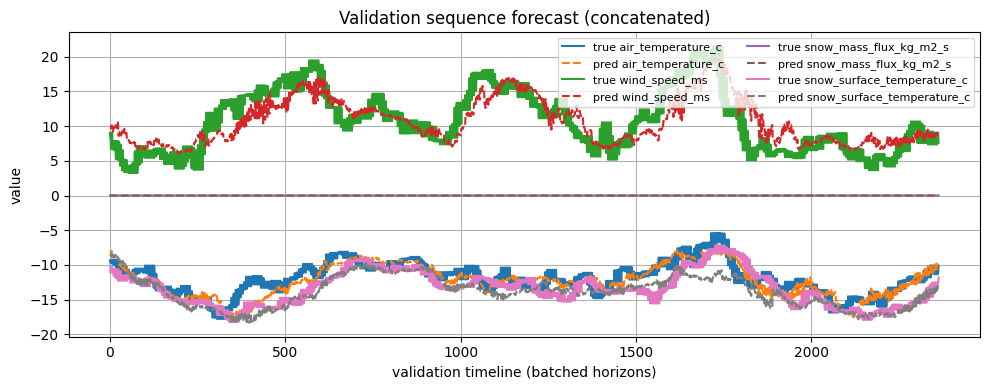

In [9]:
# Longer validation view: concatenate several batches
import numpy as np

model.eval()
all_true = []
all_pred = []
with torch.no_grad():
    for xb, fb, yb in val_loader:
        xb, fb = xb.to(device), fb.to(device)
        preds = model(xb, fb).cpu().numpy()
        all_pred.append(preds)
        all_true.append(yb.numpy())

true_arr = np.concatenate(all_true, axis=0)
pred_arr = np.concatenate(all_pred, axis=0)

true_arr = true_arr * tgt_std_vec + tgt_mean_vec
pred_arr = pred_arr * tgt_std_vec + tgt_mean_vec

# Flatten batch/time for a longer horizon view
true_flat = true_arr.reshape(-1, true_arr.shape[-1])
pred_flat = pred_arr.reshape(-1, pred_arr.shape[-1])
steps = np.arange(len(true_flat))

plt.figure(figsize=(10, 4))
for j, name in enumerate(TARGET_COLS):
    plt.plot(steps, true_flat[:, j], label=f'true {name}')
    plt.plot(steps, pred_flat[:, j], '--', label=f'pred {name}')
plt.xlabel('validation timeline (batched horizons)')
plt.ylabel('value')
plt.title('Validation sequence forecast (concatenated)')
plt.legend(ncol=2, fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()
